<a href="https://colab.research.google.com/github/seldonz03/python-bootcamp/blob/master/california_housing_prices_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import numpy as np
pd.set_option('display.max_columns', None)

# Import Dataset

In [ ]:
zip_file_path = r'/content/drive/MyDrive/Uplift Datasets/Califronia Housing Dataset.zip'
file_folder_path = r'/content/drive/MyDrive/Uplift Datasets/'

In [ ]:
with zipfile.ZipFile(zip_file_path) as zip_ref:
  zip_ref.extractall(file_folder_path)

In [ ]:
file_path = r'/content/drive/MyDrive/Uplift Datasets/housing.csv'

In [ ]:
df = pd.read_csv(file_path)

# Data Exploration

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
cols_for_histo = ['housing_median_age', 'total_rooms', 'population', 'households',
                  'median_income', 'median_house_value']

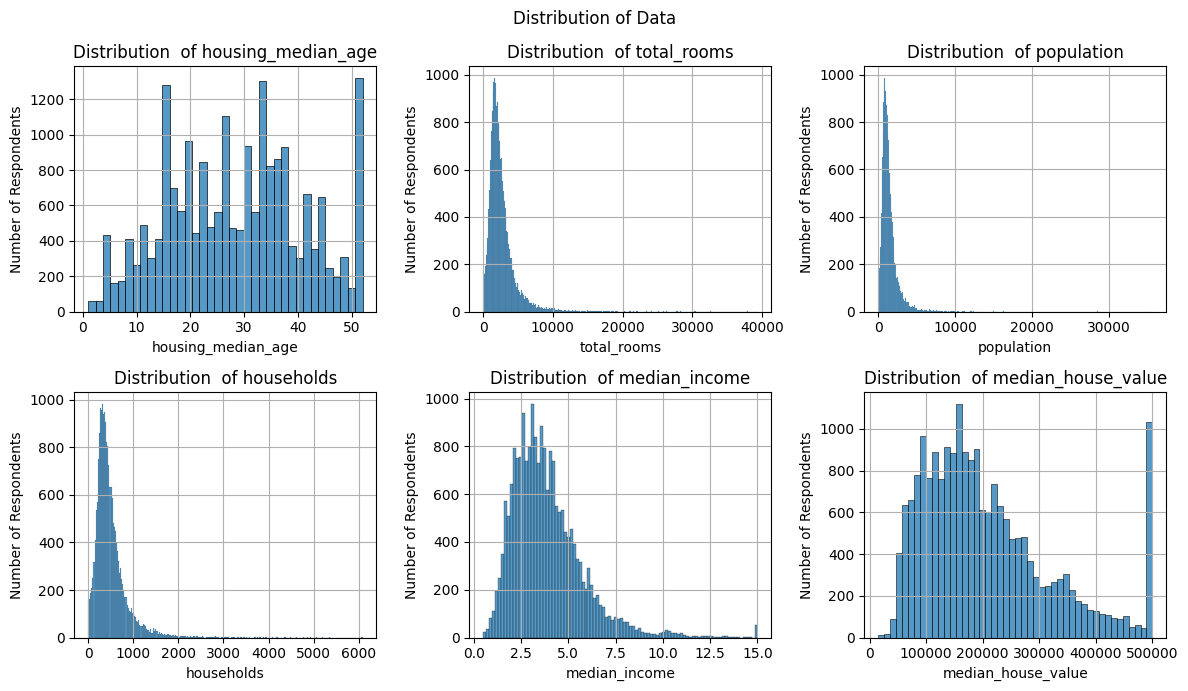

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,7))
axes = axes.flatten()
for i, column in enumerate(cols_for_histo):
  sns.histplot(data=df, x=column, ax=axes[i])
  axes[i].set_title(f'Distribution  of {column}')
  axes[i].set_xlabel(column)
  axes[i].set_ylabel('Number of Respondents')
  axes[i].grid(True)

plt.suptitle('Distribution of Data')
plt.tight_layout()
plt.show()

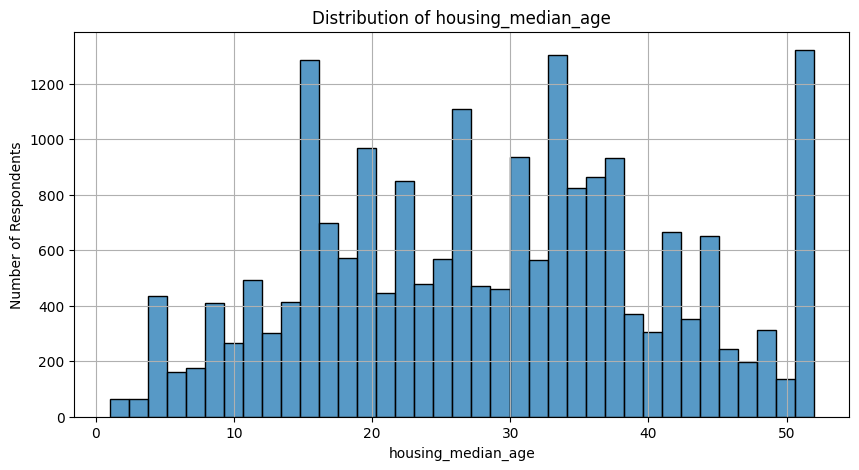

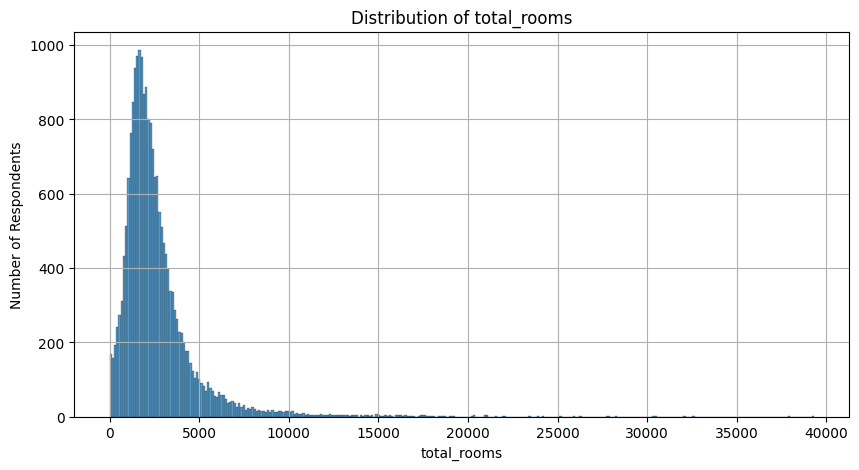

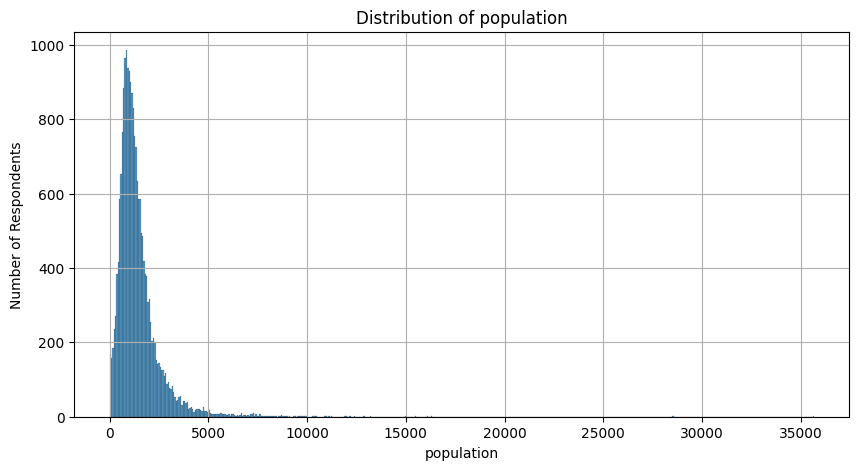

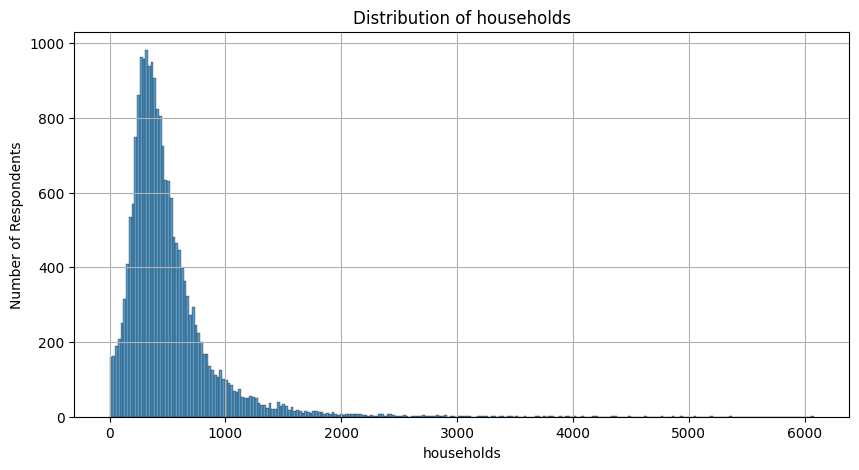

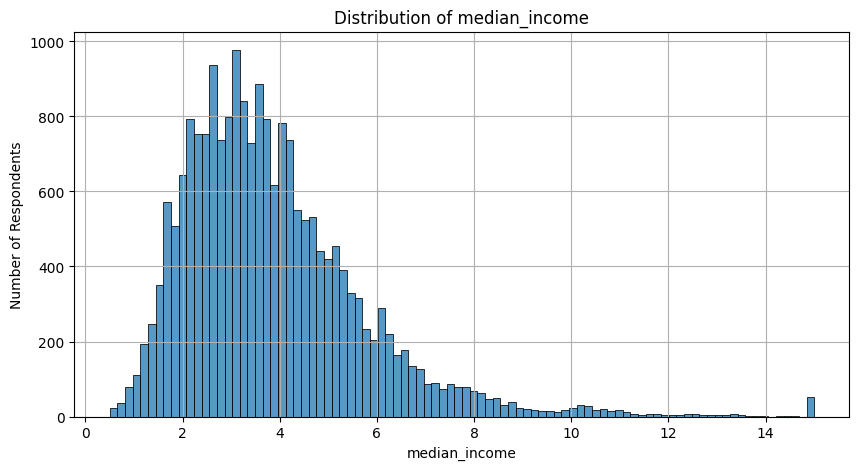

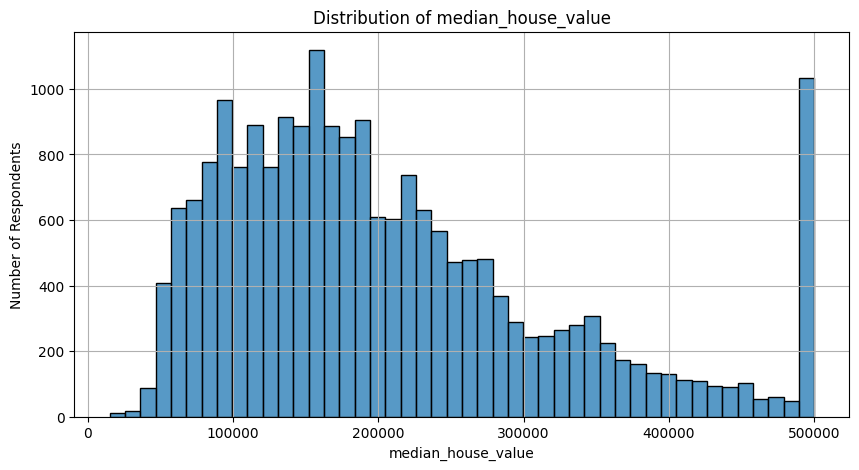

In [ ]:
for column in cols_for_histo:
  plt.figure(figsize = (10,5))
  sns.histplot(data=df, x=column)
  plt.grid(True)
  plt.title(f'Distribution of {column}')
  plt.xlabel(f'{column}')
  plt.ylabel('Number of Respondents')
  plt.show()

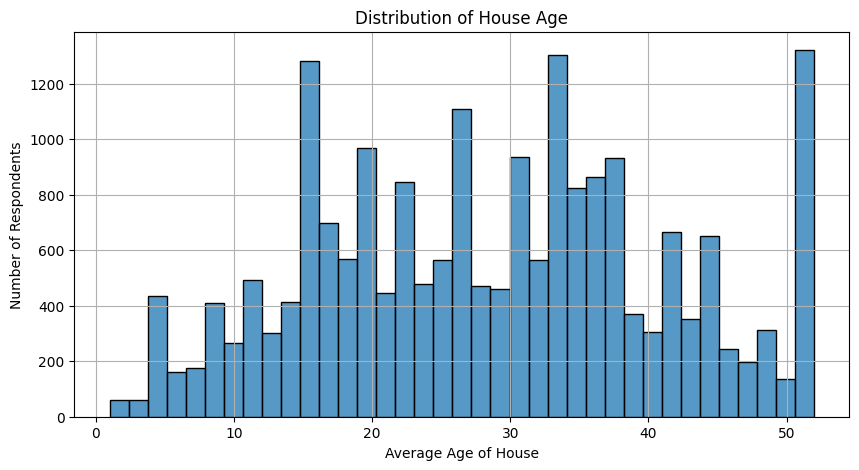

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='housing_median_age')
plt.grid(True)
plt.ylabel('Number of Respondents')
plt.xlabel('Average Age of House')
plt.title('Distribution of House Age')
plt.show()

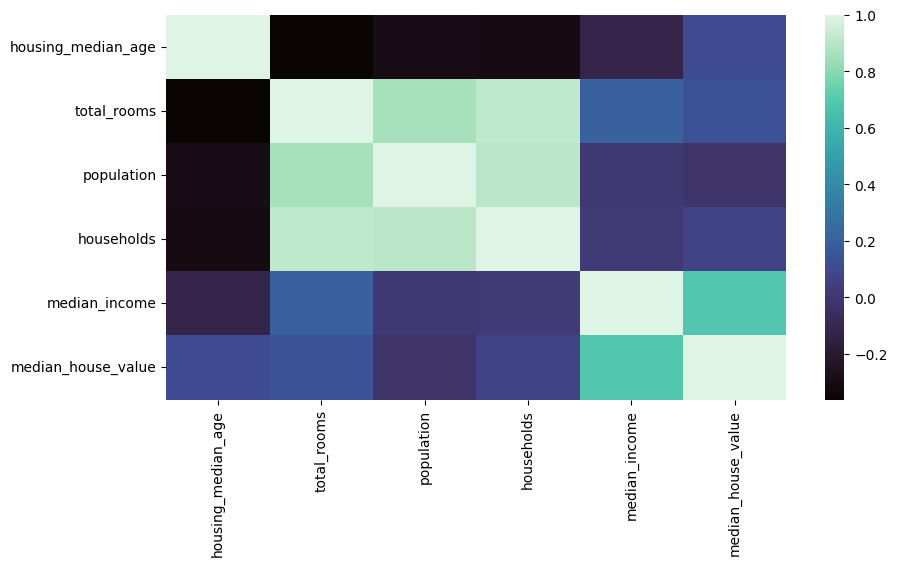

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(data=df[cols_for_histo].corr(), cmap='mako')
plt.show()

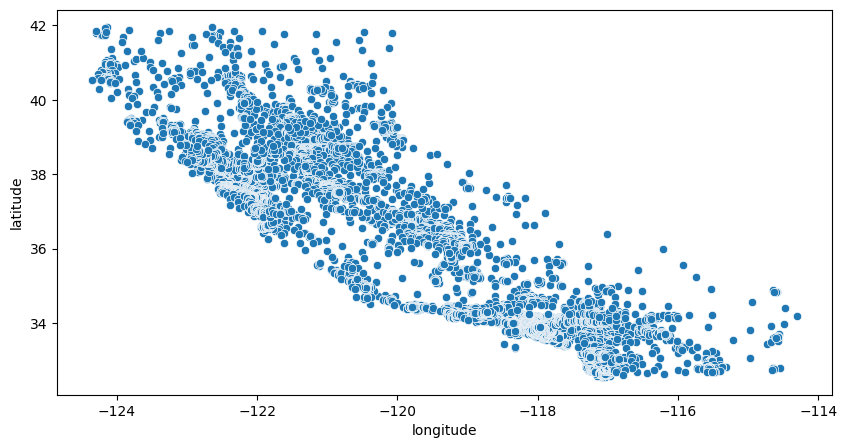

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='longitude', y='latitude')
plt.show()

# Create Test Set

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

In [ ]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


In [ ]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      3921 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   median_house_value  4128 non-null   float64
 9   ocean_proximity     4128 non-null   object 
dtypes: float64(9), object(1)
memory usage: 354.8+ KB


# Preprocessing for Machine Learning

## Data Cleaning

In [ ]:
sample_incomplete_rows = df[df.isnull().any(axis=1)]

In [ ]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


### Data Cleaning by Dropping

In [ ]:
df_clean = df.drop('total_bedrooms', axis=1) # Cleaning by dropping entire column

### Data Cleaning by Imputation

In [ ]:
median = df['total_bedrooms'].median()
sample_incomplete_rows['total_bedrooms'].fillna(median, inplace=True)

/tmp/ipython-input-2918926802.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows['total_bedrooms'].fillna(median, inplace=True)
/tmp/ipython-input-2918926802.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_incomplete_rows['total_bedrooms'].fillna(median, inplace=True)


In [ ]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,435.0,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,435.0,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,435.0,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,435.0,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,435.0,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,435.0,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,435.0,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,435.0,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,435.0,2734.0,814.0,6.6073,258100.0,<1H OCEAN


### Data Cleaning using Sklearn

In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
# For demonstration purpose only
imputer = SimpleImputer(strategy='median')
df_num = df.drop('ocean_proximity', axis=1)
imputer.fit(df_num)

SimpleImputer(strategy='median')

In [ ]:
# Do this for the actual method
imputer = SimpleImputer(strategy='median')
train_set_num = train_set.drop('ocean_proximity', axis =1)
imputer.fit(train_set_num)
X = imputer.transform(train_set_num)

train_set_imp = pd.DataFrame(X, columns=train_set_num.columns)

In [ ]:
train_set_imp

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0
1,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0
2,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0
3,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0
4,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0
...,...,...,...,...,...,...,...,...,...
16507,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0
16508,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0
16509,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0
16510,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0


### Imputation for Categorical Columns

In [ ]:
mode = df['ocean_proximity'].value_counts().index[0]
df['ocean_proximity'] = df['ocean_proximity'].fillna(mode)

## Transformations

### Encoding

### Ordinal Encoding

In [ ]:
train_set_cat = train_set[['ocean_proximity']]

In [ ]:
train_set_cat

,ocean_proximity
14196,NEAR OCEAN
8267,NEAR OCEAN
17445,NEAR OCEAN
14265,NEAR OCEAN
2271,INLAND
...,...
11284,<1H OCEAN
11964,INLAND
5390,<1H OCEAN
860,<1H OCEAN


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
train_set_cat_encoded = ordinal_encoder.fit_transform(train_set_cat)

In [ ]:
train_set_cat_encoded

array([[4.],
       [4.],
       [4.],
       ...,
       [0.],
       [0.],
       [3.]])

### One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder()
train_set_cat_1hot = ohe.fit_transform(train_set_cat)

## Transformation Pipeline

In [ ]:
x_train = train_set.drop('median_house_value', axis=1)
y_train = train_set['median_house_value']

In [ ]:
from sklearn.compose import ColumnTransformer

num_cols = x_train.copy().drop('ocean_proximity', axis=1).columns
cat_cols = ['ocean_proximity']

trans_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

In [ ]:
x_train_trans = trans_pipeline.fit_transform(x_train)

# Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import tree

In [ ]:
# Training the Decision Tree Model
decision_model = tree.DecisionTreeRegressor()
decision_model = decision_model.fit(x_train_trans, y_train)

In [ ]:
# Training the Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(x_train_trans, y_train)

LinearRegression()

# Model Testing

In [ ]:
# Transform your test set
x_test = test_set.drop('median_house_value', axis = 1)
y_test = test_set['median_house_value']

# Transform the data for ML computations
num_cols = x_test.drop('ocean_proximity', axis=1).columns
cat_cols = ['ocean_proximity']

trans_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

x_test_trans = trans_pipeline.fit_transform(x_test)

In [ ]:
lin_model_predictions = lin_reg.predict(x_test_trans)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
lin_error = mean_absolute_percentage_error(y_test, lin_model_predictions)
print(f"Linear Regression Error: {lin_error}")

Linear Regression Error: 0.2918617198724518


# End To End Pipeline

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
# Load the data
df = pd.read_csv(file_path)

In [ ]:
# Split the data into training and test
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

In [ ]:
# Split the training data into x and y variables
x_train = train_set.drop('median_house_value', axis =1)
y_train = train_set['median_house_value']

In [ ]:
# Transform the data for ML computations
num_cols = x_train.drop('ocean_proximity', axis=1).columns
cat_cols = ['ocean_proximity']

trans_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

x_train_trans = trans_pipeline.fit_transform(x_train)

In [ ]:
# Training the Decision Tree Model
decision_model = tree.DecisionTreeRegressor()
decision_model = decision_model.fit(x_train_trans, y_train)

# Training the Linear Regression Model
lin_reg = LinearRegression()
line_reg = lin_reg.fit(x_train_trans, y_train)

In [ ]:
# Transform your test set
x_test = test_set.drop('median_house_value', axis = 1)
y_test = test_set['median_house_value']

# Transform the data for ML computations
num_cols = x_test.drop('ocean_proximity', axis=1).columns
cat_cols = ['ocean_proximity']

trans_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

x_test_trans = trans_pipeline.fit_transform(x_test)

In [ ]:
# Model Predictions
lin_model_predictions = lin_reg.predict(x_test_trans)
decision_model_predictions = decision_model.predict(x_test_trans)

In [ ]:
# Measure model performance
lin_error = mean_absolute_percentage_error(y_test, lin_model_predictions)
decision_error = mean_absolute_percentage_error(y_test, decision_model_predictions)

In [ ]:
print(f"Linear Regression Error: {lin_error}")
print(f"Decision Tree Error: {decision_error}")

Linear Regression Error: 0.2918617198724518
Decision Tree Error: 0.24136001898910817


In [ ]:
lin_model_predictions

array([ 53335.92313126, 123505.81316946, 254769.85372393, ...,
       439180.98341183, 120797.55240622, 183386.04993586])

In [ ]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


In [ ]:
# Append test results to test set for comparison
test_set['House Price Predictions (Linear Model)'] = lin_model_predictions
test_set['House Price Predictions (Decision Tree Model)'] = decision_model_predictions

In [ ]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,House Price Predictions (Linear Model),House Price Predictions (Decision Tree Model)
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND,53335.923131,42500.0
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND,123505.813169,26600.0
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY,254769.853724,500001.0
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN,267282.905801,225800.0
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN,262049.909048,319800.0


# End to End Pipeline for Classification

Create a classification model that would allow us to accurately predict if a given house, based on the details such as longitude, latitude, hosue price, etc. is located near the ocean or not.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size = 0.2,
                                       stratify = df['ocean_proximity'], random_state= 42)

In [ ]:
# Split the training set into x and y variables
x_train_set = train_set.drop('ocean_proximity', axis=1)
y_train_set = train_set['ocean_proximity']

In [ ]:
# Split the numerical columns from the categorical columns
num_cols = x_train_set.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = x_train_set.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_trans = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [ ]:
# Create a transformation pipeline for data processing
from sklearn.compose import ColumnTransformer

trans_pipeline = ColumnTransformer([
    ("num",num_trans, num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

x_train_trans = trans_pipeline.fit_transform(x_train_set)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Instatiate the models
# log_model = LogisticRegression(max_iter = 100,
#                                multi_class='multinomial', random_state = 42)

# rf_model = RandomForestClassifier(n_estimators=100, random_state = 42)

tree_model = DecisionTreeClassifier()

In [ ]:
# rf_model = rf_model.fit(x_train_trans, y_train)

In [ ]:
tree_model = tree_model.fit(x_train_trans, y_train_set)

In [ ]:
# Prepare testing set for model predictions
x_test_set = test_set.drop('ocean_proximity', axis = 1)
y_test_set = test_set['ocean_proximity']

# Split the numerical columns from the categorical columns
num_cols = x_test_set.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = x_test_set.select_dtypes(include=['object', 'category']).columns.tolist()

x_test_trans = trans_pipeline.fit_transform(x_test_set)

In [ ]:
# Model Predictions
tree_model_predictions = tree_model.predict(x_test_trans)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_set, tree_model_predictions))

              precision    recall  f1-score   support

   <1H OCEAN       0.94      0.90      0.92      1827
      INLAND       0.96      0.97      0.96      1310
      ISLAND       1.00      1.00      1.00         1
    NEAR BAY       0.86      0.96      0.91       458
  NEAR OCEAN       0.82      0.85      0.83       532

    accuracy                           0.92      4128
   macro avg       0.92      0.93      0.92      4128
weighted avg       0.92      0.92      0.92      4128

